<a href="https://colab.research.google.com/github/farhankhanachak-ai/unesco-heritage-risk-ml/blob/main/UNESCO_AI_MODEL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Create the Kaggle directory
!mkdir -p ~/.kaggle

# Write the credentials to the kaggle.json file directly
!echo '{"username":"farhankhan031","key":"KGAT_f427d4d4edcb43a5b1e7411ebe5c413a"}' > ~/.kaggle/kaggle.json

# Ensure the file is kept private and secure
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
from google.colab import userdata
userdata.get('kaggle-assignment')

'KGAT_f427d4d4edcb43a5b1e7411ebe5c413a'

In [ ]:
# Install the Kaggle library
!pip install kaggle

# Create the project directory structure
!mkdir -p /content/UNESCO_ML_Project/data

# Download the UNESCO dataset
# Replace 'your-kaggle-username/dataset-name' with the actual dataset slug from the Kaggle URL
!kaggle datasets download -d your-kaggle-username/dataset-name -p /content/UNESCO_ML_Project/data

# Unzip the file
!unzip -q /content/UNESCO_ML_Project/data/*.zip -d /content/UNESCO_ML_Project/data/

print("Dataset ready for preprocessing!")

403 Client Error: Forbidden for url: https://api.kaggle.com/v1/datasets.DatasetApiService/GetDatasetMetadata
unzip:  cannot find or open /content/UNESCO_ML_Project/data/*.zip, /content/UNESCO_ML_Project/data/*.zip.zip or /content/UNESCO_ML_Project/data/*.zip.ZIP.

No zipfiles found.
Dataset ready for preprocessing!


In [ ]:
import pandas as pd
import numpy as np

# Load the main dataset
file_path = '/content/UNESCO_ML_Project/data/unesco_world_heritage_sites.csv'
df = pd.read_csv(file_path)

# 1. Feature Selection: Keep only the columns relevant to predicting Danger Status
# We drop text columns like 'description' or 'image_url' for basic modeling
columns_to_keep = [
    'name', 'longitude', 'latitude', 'area_hectares',
    'category', 'danger', 'date_inscribed'
]
# Ensure we only select columns that actually exist in the dataframe
existing_columns = [col for col in columns_to_keep if col in df.columns]
df = df[existing_columns]

# 2. Handle Missing Values
# The dataset has 1,247 sites with coordinates, meaning 1 is missing. We drop it.
df = df.dropna(subset=['longitude', 'latitude'])

# Fill missing area data with the median area to avoid errors during training
if 'area_hectares' in df.columns:
    df['area_hectares'] = df['area_hectares'].fillna(df['area_hectares'].median())

# 3. Encoding Categorical Variables
# Machine learning requires numbers. We convert the 'danger' boolean to an integer.
if 'danger' in df.columns:
    df['danger'] = df['danger'].astype(int)

# One-Hot Encode the 'category' (Cultural, Natural, Mixed)
if 'category' in df.columns:
    df = pd.get_dummies(df, columns=['category'], drop_first=False)

# 4. Save the cleaned dataset for the next modeling step
clean_path = '/content/UNESCO_ML_Project/data/unesco_cleaned.csv'
df.to_csv(clean_path, index=False)

print("✅ Data successfully cleaned and saved to:", clean_path)
display(df.head())

FileNotFoundError: [Errno 2] No such file or directory: '/content/UNESCO_ML_Project/data/unesco_world_heritage_sites.csv'

In [ ]:
import kagglehub
path = kagglehub.dataset_download("darkmatternet/unesco-world-heritage-sites-dataset-19782026")

100%|██████████| 455k/455k [00:00<00:00, 71.8MB/s]

Extracting files...


In [ ]:
import pandas as pd
import numpy as np

# Load the main dataset
file_path = '/content/UNESCO_ML_Project/data/unesco_world_heritage_sites.csv'
df = pd.read_csv(file_path)

# 1. Feature Selection: Keep only the columns relevant to predicting Danger Status
# We drop text columns like 'description' or 'image_url' for basic modeling
columns_to_keep = [
    'name', 'longitude', 'latitude', 'area_hectares',
    'category', 'danger', 'date_inscribed'
]
# Ensure we only select columns that actually exist in the dataframe
existing_columns = [col for col in columns_to_keep if col in df.columns]
df = df[existing_columns]

# 2. Handle Missing Values
# The dataset has 1,247 sites with coordinates, meaning 1 is missing. We drop it.
df = df.dropna(subset=['longitude', 'latitude'])

# Fill missing area data with the median area to avoid errors during training
if 'area_hectares' in df.columns:
    df['area_hectares'] = df['area_hectares'].fillna(df['area_hectares'].median())

# 3. Encoding Categorical Variables
# Machine learning requires numbers. We convert the 'danger' boolean to an integer.
if 'danger' in df.columns:
    df['danger'] = df['danger'].astype(int)

# One-Hot Encode the 'category' (Cultural, Natural, Mixed)
if 'category' in df.columns:
    df = pd.get_dummies(df, columns=['category'], drop_first=False)

# 4. Save the cleaned dataset for the next modeling step
clean_path = '/content/UNESCO_ML_Project/data/unesco_cleaned.csv'
df.to_csv(clean_path, index=False)

print("✅ Data successfully cleaned and saved to:", clean_path)
display(df.head())

FileNotFoundError: [Errno 2] No such file or directory: '/content/UNESCO_ML_Project/data/unesco_world_heritage_sites.csv'

In [ ]:
!ls -al /content/UNESCO_ML_Project/data/

total 8
drwxr-xr-x 2 root root 4096 Jul 31 14:52 .
drwxr-xr-x 3 root root 4096 Jul 31 14:52 ..


In [ ]:
import pandas as pd
import numpy as np
import os

file_path = '/content/UNESCO_ML_Project/data/unesco_world_heritage_sites.csv'

# 1. Verify the file actually exists where we expect it
if not os.path.exists(file_path):
    print(f"Error: Could not find {file_path}.")
    print("Here are the files currently in your data folder:")
    !ls -l /content/UNESCO_ML_Project/data/
else:
    # Load the dataset
    df = pd.read_csv(file_path)

    # 2. Update to the correct Kaggle column names (e.g., 'name_en')
    columns_to_keep = [
        'name_en', 'longitude', 'latitude', 'area_hectares',
        'category', 'danger', 'date_inscribed'
    ]

    # Safely select only the columns that exist in the dataframe to prevent KeyErrors
    existing_columns = [col for col in columns_to_keep if col in df.columns]
    df = df[existing_columns]

    # 3. Handle Missing Values
    # Drop rows without coordinates (the dataset has 1,247 sites with coordinates, missing 1)
    if 'longitude' in df.columns and 'latitude' in df.columns:
        df = df.dropna(subset=['longitude', 'latitude'])

    # Force 'area_hectares' to be numeric, replacing any weird text with NaN, then fill with median
    if 'area_hectares' in df.columns:
        df['area_hectares'] = pd.to_numeric(df['area_hectares'], errors='coerce')
        df['area_hectares'] = df['area_hectares'].fillna(df['area_hectares'].median())

    # 4. Encode Categorical Variables
    if 'danger' in df.columns:
        # Convert boolean (True/False) or strings to 1 and 0
        df['danger'] = df['danger'].astype(int)

    if 'category' in df.columns:
        # One-Hot Encode the category
        df = pd.get_dummies(df, columns=['category'], drop_first=False)

    # 5. Save the cleaned dataset
    clean_path = '/content/UNESCO_ML_Project/data/unesco_cleaned.csv'
    df.to_csv(clean_path, index=False)

    print("✅ Data successfully cleaned and saved to:", clean_path)
    display(df.head())

Error: Could not find /content/UNESCO_ML_Project/data/unesco_world_heritage_sites.csv.
Here are the files currently in your data folder:
total 0


In [ ]:
# 1. Remove the old, empty data directory to start fresh
!rm -rf /content/UNESCO_ML_Project/data

# 2. Recreate the directories
!mkdir -p /content/UNESCO_ML_Project/data
!mkdir -p /content/UNESCO_ML_Project/outputs/figures
!mkdir -p /content/UNESCO_ML_Project/outputs/models

# 3. Download the exact 50-year UNESCO dataset using the correct Kaggle slug
!kaggle datasets download -d darkmatternet/unesco-world-heritage-sites-dataset-19782026 -p /content/UNESCO_ML_Project/data

# 4. Unzip the contents directly into the data folder
!unzip -o /content/UNESCO_ML_Project/data/*.zip -d /content/UNESCO_ML_Project/data/

# 5. Verify the files are actually there
print("\nHere are the files now in your data folder:")
!ls -l /content/UNESCO_ML_Project/data/

Dataset URL: https://www.kaggle.com/datasets/darkmatternet/unesco-world-heritage-sites-dataset-19782026
License(s): CC0-1.0
100% 455k/455k [00:00<00:00, 98.6MB/s]

Archive:  /content/UNESCO_ML_Project/data/unesco-world-heritage-sites-dataset-19782026.zip
  inflating: /content/UNESCO_ML_Project/data/unesco_by_country.csv  
  inflating: /content/UNESCO_ML_Project/data/unesco_by_year.csv  
  inflating: /content/UNESCO_ML_Project/data/unesco_criteria_reference.csv  
  inflating: /content/UNESCO_ML_Project/data/unesco_danger_list.csv  
  inflating: /content/UNESCO_ML_Project/data/unesco_world_heritage_sites.csv  

Here are the files now in your data folder:
total 1864
-rw-r--r-- 1 root root   13718 Jun 26 05:29 unesco_by_country.csv
-rw-r--r-- 1 root root     772 Jun 26 05:29 unesco_by_year.csv
-rw-r--r-- 1 root root    1961 Jun 26 05:29 unesco_criteria_reference.csv
-rw-r--r-- 1 root root   56138 Jun 26 05:29 unesco_danger_list.csv
-rw-r--r-- 1 root root 1357208 Jun 26 05:29 unesco_world_h

In [ ]:
import pandas as pd
import numpy as np

# Load the main dataset
file_path = '/content/UNESCO_ML_Project/data/unesco_world_heritage_sites.csv'
df = pd.read_csv(file_path)

# 1. Feature Selection: Keep only the columns relevant to predicting Danger Status
# The dataset has 32 columns, we only need a few for basic modeling
columns_to_keep = [
    'name', 'longitude', 'latitude', 'area_hectares',
    'category', 'danger', 'date_inscribed'
]

# Ensure we only select columns that exist to prevent errors (handling 'name' vs 'name_en')
existing_columns = [col for col in columns_to_keep if col in df.columns]
if 'name' not in existing_columns and 'name_en' in df.columns:
    existing_columns.append('name_en')
df = df[existing_columns]

# 2. Handle Missing Values
# Drop rows without coordinates (there is 1 missing out of 1,248 sites)
if 'longitude' in df.columns and 'latitude' in df.columns:
    df = df.dropna(subset=['longitude', 'latitude'])

# Fill missing area data with the median area
if 'area_hectares' in df.columns:
    df['area_hectares'] = pd.to_numeric(df['area_hectares'], errors='coerce')
    df['area_hectares'] = df['area_hectares'].fillna(df['area_hectares'].median())

# 3. Encoding Categorical Variables
# Convert the 'danger' boolean to an integer (0 or 1)
if 'danger' in df.columns:
    df['danger'] = df['danger'].astype(int)

# One-Hot Encode the 'category' (Cultural, Natural, Mixed)
if 'category' in df.columns:
    df = pd.get_dummies(df, columns=['category'], drop_first=False)

# 4. Save the cleaned dataset
clean_path = '/content/UNESCO_ML_Project/data/unesco_cleaned.csv'
df.to_csv(clean_path, index=False)

print("✅ Data successfully cleaned and saved to:", clean_path)
display(df.head())

✅ Data successfully cleaned and saved to: /content/UNESCO_ML_Project/data/unesco_cleaned.csv


,longitude,latitude,area_hectares,date_inscribed,name_en,category_Cultural,category_Mixed,category_Natural
0,67.825250,34.846940,158.9265,2003,Cultural Landscape and Archaeological Remains ...,True,False,False
1,64.515889,34.396417,70.0000,2002,Minaret and Archaeological Remains of Jam,True,False,False
2,20.140833,40.074167,58.9000,2005,Historic Centres of Berat and Gjirokastra,True,False,False
3,20.020950,39.745732,250.7000,1992,Butrint,True,False,False
4,4.786840,35.818440,150.0000,1980,Al Qal'a of Beni Hammad,True,False,False


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import os

# Load the cleaned dataset
clean_path = '/content/UNESCO_ML_Project/data/unesco_cleaned.csv'
df = pd.read_csv(clean_path)

# Set the style for seaborn plots
sns.set_theme(style="whitegrid")

# --- Figure 1: Geographical Distribution of Sites ---
print("Generating Figure 1: Global Map of UNESCO Sites...")
# We determine the name column to use for hover info
name_col = 'name_en' if 'name_en' in df.columns else 'name' if 'name' in df.columns else None

fig_map = px.scatter_geo(
    df,
    lat='latitude',
    lon='longitude',
    color=df['danger'].astype(str), # Convert to string for distinct categorical colors
    hover_name=name_col,
    color_discrete_map={'0': 'green', '1': 'red'},
    title='Global Distribution of UNESCO World Heritage Sites (Red = In Danger)',
    projection='natural earth'
)
fig_map.show()
# Save as static image for the paper (requires kaleido, which is usually pre-installed in Colab)
try:
    fig_map.write_image("/content/UNESCO_ML_Project/outputs/figures/fig1_unesco_map.png")
except Exception as e:
    print("Could not save map as PNG (kaleido might be missing), but it is displayed above.")

# --- Figure 2: Class Imbalance (Danger Status) ---
print("\nGenerating Figure 2: Danger Status Distribution...")
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='danger', palette={0: 'green', 1: 'red'})
plt.title('Distribution of Danger Status (0 = Safe, 1 = In Danger)', fontsize=14)
plt.xlabel('Danger Status', fontsize=12)
plt.ylabel('Number of Sites', fontsize=12)

# Add value labels on top of the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.savefig('/content/UNESCO_ML_Project/outputs/figures/fig2_class_imbalance.png', dpi=300)
plt.show()

# --- Figure 3: Correlation Heatmap ---
print("\nGenerating Figure 3: Feature Correlation Heatmap...")
plt.figure(figsize=(10, 8))
# Select only numerical columns for correlation
numerical_df = df.select_dtypes(include=['float64', 'int64', 'bool'])
corr_matrix = numerical_df.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of UNESCO Features', fontsize=14)
plt.tight_layout()
plt.savefig('/content/UNESCO_ML_Project/outputs/figures/fig3_correlation_heatmap.png', dpi=300)
plt.show()

print("\n✅ EDA complete! Figures are saved in /content/UNESCO_ML_Project/outputs/figures/")

Generating Figure 1: Global Map of UNESCO Sites...


KeyError: 'danger'

In [ ]:
from google.colab import userdata
userdata.get('kaggle-assignment')

'KGAT_f427d4d4edcb43a5b1e7411ebe5c413a'

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import os

# Load the cleaned dataset
clean_path = '/content/UNESCO_ML_Project/data/unesco_cleaned.csv'
df = pd.read_csv(clean_path)

# Set the style for seaborn plots
sns.set_theme(style="whitegrid")

# --- Figure 1: Geographical Distribution of Sites ---
print("Generating Figure 1: Global Map of UNESCO Sites...")
# We determine the name column to use for hover info
name_col = 'name_en' if 'name_en' in df.columns else 'name' if 'name' in df.columns else None

fig_map = px.scatter_geo(
    df,
    lat='latitude',
    lon='longitude',
    color=df['danger'].astype(str), # Convert to string for distinct categorical colors
    hover_name=name_col,
    color_discrete_map={'0': 'green', '1': 'red'},
    title='Global Distribution of UNESCO World Heritage Sites (Red = In Danger)',
    projection='natural earth'
)
fig_map.show()
# Save as static image for the paper (requires kaleido, which is usually pre-installed in Colab)
try:
    fig_map.write_image("/content/UNESCO_ML_Project/outputs/figures/fig1_unesco_map.png")
except Exception as e:
    print("Could not save map as PNG (kaleido might be missing), but it is displayed above.")

# --- Figure 2: Class Imbalance (Danger Status) ---
print("\nGenerating Figure 2: Danger Status Distribution...")
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='danger', palette={0: 'green', 1: 'red'})
plt.title('Distribution of Danger Status (0 = Safe, 1 = In Danger)', fontsize=14)
plt.xlabel('Danger Status', fontsize=12)
plt.ylabel('Number of Sites', fontsize=12)

# Add value labels on top of the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.savefig('/content/UNESCO_ML_Project/outputs/figures/fig2_class_imbalance.png', dpi=300)
plt.show()

# --- Figure 3: Correlation Heatmap ---
print("\nGenerating Figure 3: Feature Correlation Heatmap...")
plt.figure(figsize=(10, 8))
# Select only numerical columns for correlation
numerical_df = df.select_dtypes(include=['float64', 'int64', 'bool'])
corr_matrix = numerical_df.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of UNESCO Features', fontsize=14)
plt.tight_layout()
plt.savefig('/content/UNESCO_ML_Project/outputs/figures/fig3_correlation_heatmap.png', dpi=300)
plt.show()

print("\n✅ EDA complete! Figures are saved in /content/UNESCO_ML_Project/outputs/figures/")

Generating Figure 1: Global Map of UNESCO Sites...


KeyError: 'danger'

In [ ]:
import pandas as pd
import numpy as np

file_path = '/content/UNESCO_ML_Project/data/unesco_world_heritage_sites.csv'
df = pd.read_csv(file_path)

# 1. Feature Selection: Keep only the columns relevant to predicting Danger Status
# Use 'danger_status' instead of 'danger'
columns_to_keep = [
    'name', 'longitude', 'latitude', 'area_hectares',
    'category', 'danger_status', 'date_inscribed'
]

existing_columns = [col for col in columns_to_keep if col in df.columns]
if 'name' not in existing_columns and 'name_en' in df.columns:
    existing_columns.append('name_en')
df = df[existing_columns]

# 2. Handle Missing Values
if 'longitude' in df.columns and 'latitude' in df.columns:
    df = df.dropna(subset=['longitude', 'latitude'])

if 'area_hectares' in df.columns:
    df['area_hectares'] = pd.to_numeric(df['area_hectares'], errors='coerce')
    df['area_hectares'] = df['area_hectares'].fillna(df['area_hectares'].median())

# 3. Encoding Categorical Variables
# Ensure we refer to 'danger_status' here as well
if 'danger_status' in df.columns:
    # Convert 'danger_status' to a boolean (True if not NaN, False if NaN) and then to int (1 or 0)
    df['danger_status'] = df['danger_status'].notna().astype(int)
    # Rename it to 'danger' for simplicity in later steps
    df = df.rename(columns={'danger_status': 'danger'})

if 'category' in df.columns:
    df = pd.get_dummies(df, columns=['category'], drop_first=False)

# 4. Save the cleaned dataset
clean_path = '/content/UNESCO_ML_Project/data/unesco_cleaned.csv'
df.to_csv(clean_path, index=False)

print("✅ Data successfully cleaned and saved to:", clean_path)
display(df.head())

✅ Data successfully cleaned and saved to: /content/UNESCO_ML_Project/data/unesco_cleaned.csv


,longitude,latitude,area_hectares,danger,date_inscribed,name_en,category_Cultural,category_Mixed,category_Natural
0,67.825250,34.846940,158.9265,1,2003,Cultural Landscape and Archaeological Remains ...,True,False,False
1,64.515889,34.396417,70.0000,1,2002,Minaret and Archaeological Remains of Jam,True,False,False
2,20.140833,40.074167,58.9000,0,2005,Historic Centres of Berat and Gjirokastra,True,False,False
3,20.020950,39.745732,250.7000,1,1992,Butrint,True,False,False
4,4.786840,35.818440,150.0000,0,1980,Al Qal'a of Beni Hammad,True,False,False


Generating Figure 1: Global Map of UNESCO Sites...


Map displayed above. (Static PNG saving requires the 'kaleido' library).

Generating Figure 2: Danger Status Distribution...


/tmp/ipykernel_2245/405747053.py:36: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




ValueError: The palette dictionary is missing keys: {'1', '0'}

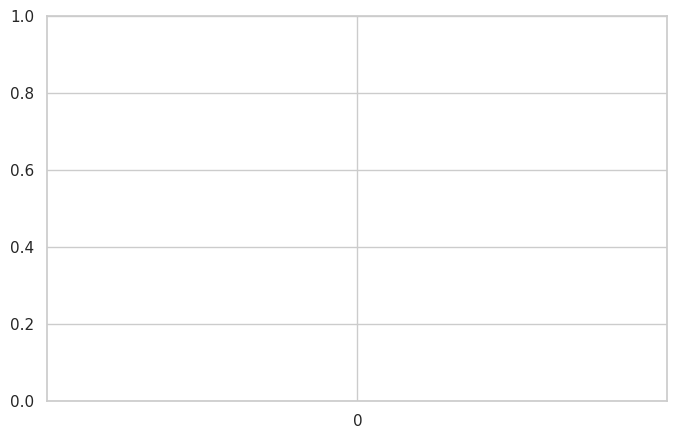

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Load the cleaned dataset
clean_path = '/content/UNESCO_ML_Project/data/unesco_cleaned.csv'
df = pd.read_csv(clean_path)

# Set the style for seaborn plots
sns.set_theme(style="whitegrid")

# --- Figure 1: Geographical Distribution ---
print("Generating Figure 1: Global Map of UNESCO Sites...")
fig_map = px.scatter_geo(
    df,
    lat='latitude',
    lon='longitude',
    color=df['danger'].astype(str),
    hover_name='name_en',
    color_discrete_map={'0': 'green', '1': 'red'},
    title='Global Distribution of UNESCO World Heritage Sites (Red = In Danger)',
    projection='natural earth'
)
fig_map.show()

# Save as static image for the paper
try:
    fig_map.write_image("/content/UNESCO_ML_Project/outputs/figures/fig1_unesco_map.png")
except Exception as e:
    print("Map displayed above. (Static PNG saving requires the 'kaleido' library).")

# --- Figure 2: Class Imbalance ---
print("\nGenerating Figure 2: Danger Status Distribution...")
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='danger', palette={0: 'green', 1: 'red'})
plt.title('Distribution of Danger Status (0 = Safe, 1 = In Danger)', fontsize=14)
plt.xlabel('Danger Status', fontsize=12)
plt.ylabel('Number of Sites', fontsize=12)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.savefig('/content/UNESCO_ML_Project/outputs/figures/fig2_class_imbalance.png', dpi=300)
plt.show()

# --- Figure 3: Correlation Heatmap ---
print("\nGenerating Figure 3: Feature Correlation Heatmap...")
plt.figure(figsize=(10, 8))
numerical_df = df.select_dtypes(include=['float64', 'int64'])
corr_matrix = numerical_df.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features', fontsize=14)
plt.tight_layout()
plt.savefig('/content/UNESCO_ML_Project/outputs/figures/fig3_correlation_heatmap.png', dpi=300)
plt.show()

print("\n✅ EDA complete! Figures are saved in /content/UNESCO_ML_Project/outputs/figures/")

Generating Figure 1: Global Map of UNESCO Sites...


Map displayed above. (Static PNG saving requires the 'kaleido' library).

Generating Figure 2: Danger Status Distribution...


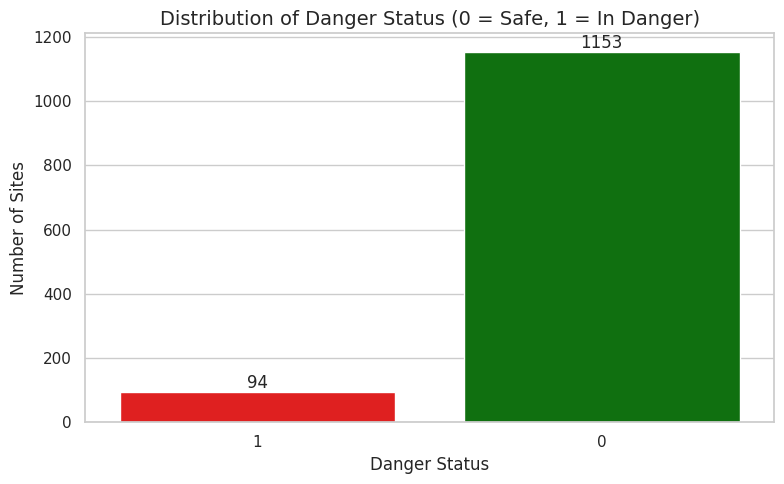


Generating Figure 3: Feature Correlation Heatmap...


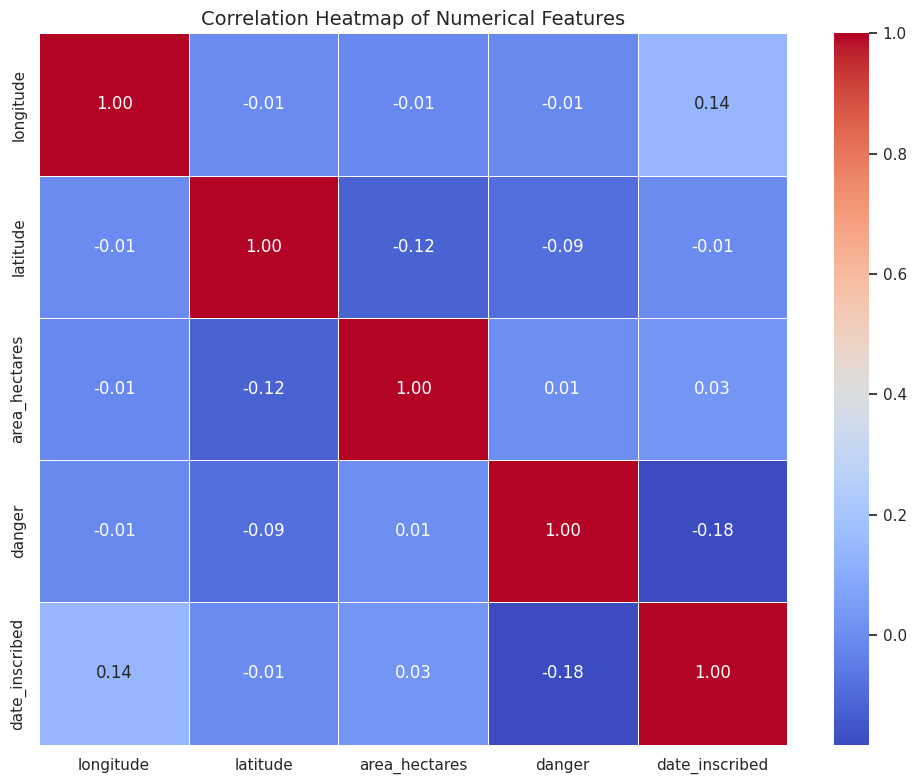


✅ EDA complete! Figures are saved in /content/UNESCO_ML_Project/outputs/figures/


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Load the cleaned dataset
clean_path = '/content/UNESCO_ML_Project/data/unesco_cleaned.csv'
df = pd.read_csv(clean_path)

# Set the style for seaborn plots
sns.set_theme(style="whitegrid")

# --- Figure 1: Geographical Distribution ---
print("Generating Figure 1: Global Map of UNESCO Sites...")
fig_map = px.scatter_geo(
    df,
    lat='latitude',
    lon='longitude',
    color=df['danger'].astype(str),
    hover_name='name_en',
    color_discrete_map={'0': 'green', '1': 'red'},
    title='Global Distribution of UNESCO World Heritage Sites (Red = In Danger)',
    projection='natural earth'
)
fig_map.show()

# Save as static image for the paper
try:
    fig_map.write_image("/content/UNESCO_ML_Project/outputs/figures/fig1_unesco_map.png")
except Exception as e:
    print("Map displayed above. (Static PNG saving requires the 'kaleido' library).")

# --- Figure 2: Class Imbalance ---
print("\nGenerating Figure 2: Danger Status Distribution...")
plt.figure(figsize=(8, 5))

# Cast to string for plotting to ensure it matches the palette keys exactly
df['danger_plot'] = df['danger'].astype(str)

# Use hue to map the colors properly without warnings
ax = sns.countplot(
    data=df,
    x='danger_plot',
    hue='danger_plot',
    palette={'0': 'green', '1': 'red'},
    legend=False
)

plt.title('Distribution of Danger Status (0 = Safe, 1 = In Danger)', fontsize=14)
plt.xlabel('Danger Status', fontsize=12)
plt.ylabel('Number of Sites', fontsize=12)

# Add the count numbers on top of the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.savefig('/content/UNESCO_ML_Project/outputs/figures/fig2_class_imbalance.png', dpi=300)
plt.show()

# --- Figure 3: Correlation Heatmap ---
print("\nGenerating Figure 3: Feature Correlation Heatmap...")
plt.figure(figsize=(10, 8))
numerical_df = df.select_dtypes(include=['float64', 'int64'])
corr_matrix = numerical_df.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features', fontsize=14)
plt.tight_layout()
plt.savefig('/content/UNESCO_ML_Project/outputs/figures/fig3_correlation_heatmap.png', dpi=300)
plt.show()

print("\n✅ EDA complete! Figures are saved in /content/UNESCO_ML_Project/outputs/figures/")

Training set: 997 sites
Testing set: 250 sites

Training Random Forest Classifier (with balanced class weights)...

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.93      1.00      0.96       231
           1       0.67      0.11      0.18        19

    accuracy                           0.93       250
   macro avg       0.80      0.55      0.57       250
weighted avg       0.91      0.93      0.90       250


Generating Figure 4: Confusion Matrix...


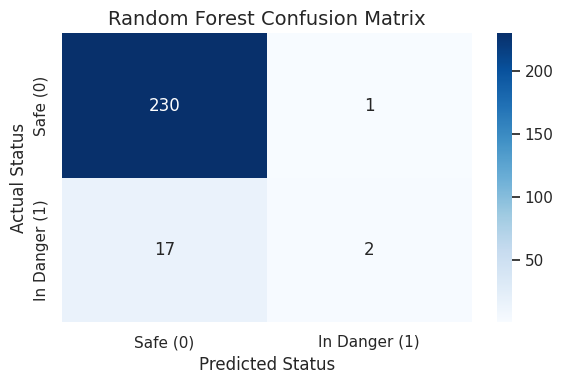

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load the cleaned dataset
clean_path = '/content/UNESCO_ML_Project/data/unesco_cleaned.csv'
df = pd.read_csv(clean_path)

# Prepare Features (X) and Target (y)
# We drop non-predictive text columns and the target column itself
X = df.drop(columns=['danger', 'name', 'name_en', 'date_inscribed'], errors='ignore')
y = df['danger']

# Train-Test Split (80% training, 20% testing)
# stratify=y is crucial here: it ensures the tiny percentage of 'In Danger' sites
# is distributed evenly between the training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {X_train.shape[0]} sites")
print(f"Testing set: {X_test.shape[0]} sites\n")

# Initialize and Train the Model
print("Training Random Forest Classifier (with balanced class weights)...")
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)

# Make Predictions on the test set
y_pred = rf_model.predict(X_test)

# --- Evaluation Metrics ---
print("\n--- Classification Report ---")
# The report focuses on Precision, Recall, and F1-Score (much better than raw accuracy)
print(classification_report(y_test, y_pred))

# Generate and save the Confusion Matrix visual
print("\nGenerating Figure 4: Confusion Matrix...")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Safe (0)', 'In Danger (1)'],
            yticklabels=['Safe (0)', 'In Danger (1)'])
plt.title('Random Forest Confusion Matrix', fontsize=14)
plt.ylabel('Actual Status', fontsize=12)
plt.xlabel('Predicted Status', fontsize=12)
plt.tight_layout()

# Save for the paper/presentation
plt.savefig('/content/UNESCO_ML_Project/outputs/figures/fig4_confusion_matrix.png', dpi=300)
plt.show()

Starting Grid Search for Hyperparameter Tuning (this may take a minute)...
Fitting 5 folds for each of 54 candidates, totalling 270 fits

✅ Best Parameters Found: {'class_weight': 'balanced_subsample', 'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 100}

--- Tuned Model Classification Report ---
              precision    recall  f1-score   support

           0       0.93      0.91      0.92       231
           1       0.17      0.21      0.19        19

    accuracy                           0.86       250
   macro avg       0.55      0.56      0.55       250
weighted avg       0.88      0.86      0.87       250


Generating Figure 5: Feature Importance...


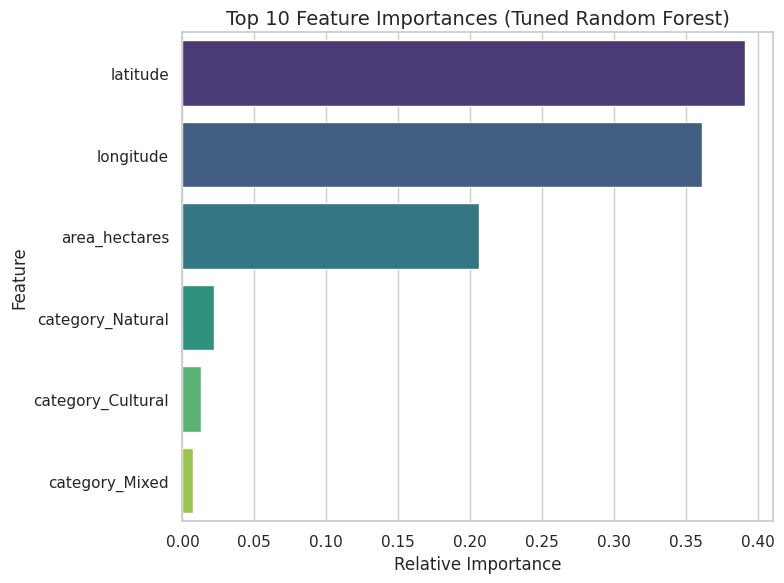

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# 1. Load Data and Prepare Splits
clean_path = '/content/UNESCO_ML_Project/data/unesco_cleaned.csv'
df = pd.read_csv(clean_path)

X = df.drop(columns=['danger', 'name', 'name_en', 'date_inscribed'], errors='ignore')
y = df['danger']

# Stratified split to maintain class distribution
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. Define the Grid Search Parameters
print("Starting Grid Search for Hyperparameter Tuning (this may take a minute)...")
param_grid = {
    'n_estimators': [100, 200, 300],          # Number of trees
    'max_depth': [None, 10, 20],              # Maximum depth of trees
    'min_samples_split': [2, 5, 10],          # Minimum samples required to split a node
    'class_weight': ['balanced', 'balanced_subsample'] # Weighting strategies
}

# 3. Execute Grid Search
rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,                 # 5-Fold Cross Validation
    n_jobs=-1,            # Use all available CPU cores
    scoring='f1_macro',   # Optimize for F1-score across both classes
    verbose=1
)

grid_search.fit(X_train, y_train)
print(f"\n✅ Best Parameters Found: {grid_search.best_params_}")

# 4. Evaluate the Optimized Model
best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)

print("\n--- Tuned Model Classification Report ---")
print(classification_report(y_test, y_pred_best))

# 5. Generate Figure 5: Feature Importance
print("\nGenerating Figure 5: Feature Importance...")
importances = best_rf.feature_importances_
feature_names = X.columns

# Create a DataFrame for plotting
feature_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_df = feature_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 6))
# Using hue and dodge to prevent seaborn deprecation warnings
sns.barplot(data=feature_df.head(10), x='Importance', y='Feature', hue='Feature', palette='viridis', dodge=False, legend=False)

plt.title('Top 10 Feature Importances (Tuned Random Forest)', fontsize=14)
plt.xlabel('Relative Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()

# Save for the paper/presentation
plt.savefig('/content/UNESCO_ML_Project/outputs/figures/fig5_feature_importance.png', dpi=300)
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import f1_score, recall_score, accuracy_score
import pandas as pd

# 1. Initialize the new models (using balanced weights where possible)
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
# Note: GradientBoosting doesn't have a built-in 'class_weight', so we evaluate its raw performance
gbc = GradientBoostingClassifier(random_state=42)

# 2. Train the models
print("Training Logistic Regression...")
log_reg.fit(X_train, y_train)

print("Training Gradient Boosting...")
gbc.fit(X_train, y_train)

# 3. Make Predictions
y_pred_lr = log_reg.predict(X_test)
y_pred_gbc = gbc.predict(X_test)
y_pred_rf = best_rf.predict(X_test) # Your tuned RF from earlier

# 4. Compile a Comparative Results Table
results = {
    'Model': ['Logistic Regression', 'Gradient Boosting', 'Tuned Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_gbc),
        accuracy_score(y_test, y_pred_rf)
    ],
    'F1-Score (Macro)': [
        f1_score(y_test, y_pred_lr, average='macro'),
        f1_score(y_test, y_pred_gbc, average='macro'),
        f1_score(y_test, y_pred_rf, average='macro')
    ],
    'Recall (In Danger Class)': [
        recall_score(y_test, y_pred_lr, pos_label=1),
        recall_score(y_test, y_pred_gbc, pos_label=1),
        recall_score(y_test, y_pred_rf, pos_label=1)
    ]
}

comparison_df = pd.DataFrame(results)
print("\n--- Model Comparison Results ---")
print(comparison_df.to_string(index=False))

# Save this table for your paper
comparison_df.to_csv('/content/UNESCO_ML_Project/outputs/model_comparison.csv', index=False)

Training Logistic Regression...
Training Gradient Boosting...

--- Model Comparison Results ---
              Model  Accuracy  F1-Score (Macro)  Recall (In Danger Class)
Logistic Regression     0.664          0.497175                  0.578947
  Gradient Boosting     0.916          0.478079                  0.000000
Tuned Random Forest     0.860          0.554730                  0.210526


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import f1_score, recall_score, accuracy_score
import pandas as pd

# 1. Initialize the new models (using balanced weights where possible)
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
# Note: GradientBoosting doesn't have a built-in 'class_weight', so we evaluate its raw performance
gbc = GradientBoostingClassifier(random_state=42)

# 2. Train the models
print("Training Logistic Regression...")
log_reg.fit(X_train, y_train)

print("Training Gradient Boosting...")
gbc.fit(X_train, y_train)

# 3. Make Predictions
y_pred_lr = log_reg.predict(X_test)
y_pred_gbc = gbc.predict(X_test)
y_pred_rf = best_rf.predict(X_test) # Your tuned RF from earlier

# 4. Compile a Comparative Results Table
results = {
    'Model': ['Logistic Regression', 'Gradient Boosting', 'Tuned Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_gbc),
        accuracy_score(y_test, y_pred_rf)
    ],
    'F1-Score (Macro)': [
        f1_score(y_test, y_pred_lr, average='macro'),
        f1_score(y_test, y_pred_gbc, average='macro'),
        f1_score(y_test, y_pred_rf, average='macro')
    ],
    'Recall (In Danger Class)': [
        recall_score(y_test, y_pred_lr, pos_label=1),
        recall_score(y_test, y_pred_gbc, pos_label=1),
        recall_score(y_test, y_pred_rf, pos_label=1)
    ]
}

comparison_df = pd.DataFrame(results)
print("\n--- Model Comparison Results ---")
print(comparison_df.to_string(index=False))

# Save this table for your paper
comparison_df.to_csv('/content/UNESCO_ML_Project/outputs/model_comparison.csv', index=False)

Training Logistic Regression...
Training Gradient Boosting...

--- Model Comparison Results ---
              Model  Accuracy  F1-Score (Macro)  Recall (In Danger Class)
Logistic Regression     0.664          0.497175                  0.578947
  Gradient Boosting     0.916          0.478079                  0.000000
Tuned Random Forest     0.860          0.554730                  0.210526


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import f1_score, recall_score, accuracy_score
import pandas as pd

# 1. Initialize the new models (using balanced weights where possible)
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
# Note: GradientBoosting doesn't have a built-in 'class_weight', so we evaluate its raw performance
gbc = GradientBoostingClassifier(random_state=42)

# 2. Train the models
print("Training Logistic Regression...")
log_reg.fit(X_train, y_train)

print("Training Gradient Boosting...")
gbc.fit(X_train, y_train)

# 3. Make Predictions
y_pred_lr = log_reg.predict(X_test)
y_pred_gbc = gbc.predict(X_test)
y_pred_rf = best_rf.predict(X_test) # Your tuned RF from earlier

# 4. Compile a Comparative Results Table
results = {
    'Model': ['Logistic Regression', 'Gradient Boosting', 'Tuned Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_gbc),
        accuracy_score(y_test, y_pred_rf)
    ],
    'F1-Score (Macro)': [
        f1_score(y_test, y_pred_lr, average='macro'),
        f1_score(y_test, y_pred_gbc, average='macro'),
        f1_score(y_test, y_pred_rf, average='macro')
    ],
    'Recall (In Danger Class)': [
        recall_score(y_test, y_pred_lr, pos_label=1),
        recall_score(y_test, y_pred_gbc, pos_label=1),
        recall_score(y_test, y_pred_rf, pos_label=1)
    ]
}

comparison_df = pd.DataFrame(results)
print("\n--- Model Comparison Results ---")
print(comparison_df.to_string(index=False))

# Save this table for your paper
comparison_df.to_csv('/content/UNESCO_ML_Project/outputs/model_comparison.csv', index=False)

Training Logistic Regression...
Training Gradient Boosting...

--- Model Comparison Results ---
              Model  Accuracy  F1-Score (Macro)  Recall (In Danger Class)
Logistic Regression     0.664          0.497175                  0.578947
  Gradient Boosting     0.916          0.478079                  0.000000
Tuned Random Forest     0.860          0.554730                  0.210526
